# Binary Classification

Linear regression outputs values from $-\infty$ to $+\infty$. A prediction of $\hat{y} = 1.8$ or $\hat{y} = -0.4$ makes no sense when target probabilities must strictly lie in the interval $[0, 1]$. That's why Linear Regression fails for classification.

To fix this, we need a mathematical function that takes any real number $z \in (-\infty, +\infty)$ from our linear model ($z = \mathbf{X}\mathbf{W}$) and compresses (squashes) it into a probability $p \in (0, 1)$.



## Deriving the Sigmoid (Logistic Function)

**Step 1: The Odds Ratio**

In probability and statistics, the odds of an event is the ratio of the probability that the event will happen to the probability that it will not happen.

$$\text{Odds} = \frac{p}{1 - p}$$

- As $p \to 1$, $\text{Odds} \to +\infty$.
- As $p \to 0$, $\text{Odds} \to 0$.


**Step 2: The Log-Odds (Logit Function)**

The Odds ratio is bounded below by $0$. To stretch the range to $(-\infty, +\infty)$ so it can equal our linear model $\mathbf{X}\mathbf{W}$, we take the natural logarithm of the odds:$$\text{Logit}(p) = \ln\left(\frac{p}{1 - p}\right) = z = \mathbf{X}\mathbf{W}$$

**Step 3: Inverting Logit to Solve for $p$ (The Sigmoid)**

$$\frac{p}{1 - p} = e^z$$
$$p = e^z (1 - p) = e^z - p \cdot e^z$$
$$p + p \cdot e^z = e^z$$
$$p(1 + e^z) = e^z$$
$$p = \frac{e^z}{1 + e^z}$$

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- When $z = 0 \implies \sigma(0) = \frac{1}{1 + e^0} = \mathbf{0.5}$
- As $z \to +\infty \implies e^{-z} \to 0 \implies \sigma(z) \to \mathbf{1.0}$
- As $z \to -\infty \implies e^{-z} \to \infty \implies \sigma(z) \to \mathbf{0.0}$

## Derivative of Sigmoid Function

$$\sigma (z)=\frac{1}{1+e^{-z}}=(1+e^{-z})^{-1}$$

$$\frac{d}{dz}[\sigma (z)]=-1\cdot (1+e^{-z})^{-2}\cdot \frac{d}{dz}(1+e^{-z})$$

$$\frac{d}{dz}[\sigma (z)]=-1\cdot (1+e^{-z})^{-2}\cdot (-e^{-z})$$

$$\frac{d}{dz}[\sigma (z)]=\frac{e^{-z}}{(1+e^{-z})^{2}}$$

$$\frac{d}{dz}[\sigma (z)]=\frac{1}{1+e^{-z}}\cdot \frac{e^{-z}}{1+e^{-z}}$$

$$\frac{d}{dz}[\sigma (z)]=\sigma (z)\cdot \frac{e^{-z}}{1+e^{-z}}$$

$$\frac{d}{dz}[\sigma (z)]=\sigma (z)\cdot \frac{1+e^{-z}-1}{1+e^{-z}}$$

$$\frac{d}{dz}[\sigma (z)]=\sigma (z)\cdot \frac{1+e^{-z}}{1+e^{-z}} - \frac{1}{1+e^{-z}}$$

$$\frac{d}{dz}[\sigma (z)]=\sigma (z)\cdot 1 - \sigma (z)$$

$$\frac{d}{dz}[\sigma (z)]=\sigma (z)(1-\sigma (z))$$


## Deriving Loss Function

**Why MSE didn't work here?**

If you combine the squared error formula of MSE with the curved S-shape of the sigmoid function, then non-convex surface (in case of linear regression a convex shape was formed) is formed which leads the model's weights to get permanently trapped in a local minumum. Also the Grdient Vanishing Problem also arise (due to the presence of $\sigma (z)(1-\sigma (z)))$

**Terminologies**

1. **Likelihood**: We have the data, and we are trying to find the **parameters** (the hidden truths that cause the results, e.g. conversation is one of the parameter of selling product)
2. **Likelihood Function**: It is the exact formula that scores each guess to show which one wins.
3. **Maximum Likelihood Estimation (MLE)**:  MLE is the actual action of picking the highest-scoring guess from that likelihood function.
4. **Bernoulli distribution**: It is a discrete probability distribution for a random variable that has exactly two possible outcomes: Success (1) and failure (0)
5. **Probability Mass Function** : PMF is a mathematical rule that assigns a specific probability value to each outcome of  a random discrete variable, based on two assumptions (The probability must be 0 or higher and the combined probability of all possible outcomes must equal exactly 1)

**Probability vs. Likelihood**

They look like the same thing, but they look at a situation from opposite directions:

-  Probability asks: "If I know the coin is fair, what is the chance I will get 10 heads?" (Parameters are fixed -> predicting data).
-  Likelihood asks: "Since I just got 10 heads, how smart is it to guess that the coin is fair?" (Data is fixed -> evaluating guesses).


1. **The Probability Mass Function**


For a single sample $i$, the predicted probability that $y_i = 1$ is $\hat{y}_i$. The probability that $y_i = 0$ is $(1 - \hat{y}_i)$:

- $P(Y_i = 1 \mid \mathbf{x}_i) = \hat{y}_i$
- $P(Y_i = 0 \mid \mathbf{x}_i) = 1 - \hat{y}_i$

We can combine these two statements into a single, compact mathematical expression using exponents:

$$P(Y_i = y_i \mid \mathbf{x}_i) = \hat{y}_i^{y_i} (1 - \hat{y}_i)^{(1 - y_i)}$$

- If $y_i = 1 \implies \hat{y}_i^1 (1 - \hat{y}_i)^0 = \mathbf{\hat{y}_i}$
- If $y_i = 0 \implies \hat{y}_i^0 (1 - \hat{y}_i)^1 = \mathbf{1 - \hat{y}_i}$

2. **The Likelihood Function $L(\mathbf{W})$**

Assuming all $N$ data samples are independent and identically distributed (i.i.d.), the total Likelihood of our entire dataset is the product of individual probabilities:

$$L(\mathbf{W}) = \prod_{i=1}^{N} P(Y_i = y_i \mid \mathbf{x}_i) = \prod_{i=1}^{N} \hat{y}_i^{y_i} (1 - \hat{y}_i)^{(1 - y_i)}$$

Our goal is to find weights $\mathbf{W}$ that maximize this likelihood function.

3. **Taking the Log-Likelihood $\ell(\mathbf{W})$**

Multiplying $N$ tiny probabilities together in computer memory leads to numerical underflow (the numbers become so small they collapse to 0).

To fix this, we apply the natural logarithm ($\ln$), converting the product ($\prod$) into a sum ($\sum$):

$$\ell(\mathbf{W}) = \ln\left( \prod_{i=1}^{N} \hat{y}_i^{y_i} (1 - \hat{y}_i)^{(1 - y_i)} \right)$$

Using log rules ($\ln(a \cdot b) = \ln(a) + \ln(b)$ and $\ln(a^b) = b \ln(a)$):
$$\ell(\mathbf{W}) = \sum_{i=1}^{N} \left[ y_i \ln(\hat{y}_i) + (1 - y_i) \ln(1 - \hat{y}_i) \right]$$

4. **From Maximum Likelihood to Cost Function $J(\mathbf{W})$**

In machine learning, optimization algorithms are designed to minimize loss rather than maximize likelihood.

To convert our Log-Likelihood into a minimization problem, we:
- Multiply by $-1$ (flipping it to Negative Log-Likelihood).
- Divide by $N$ to get the average loss per sample.


This yields the official Binary Cross-Entropy (Log-Loss) cost function:
$$J(\mathbf{W}) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \ln(\hat{y}_i) + (1 - y_i) \ln(1 - \hat{y}_i) \right]$$

where $\hat{y}_i = \sigma(\mathbf{x}_i^T \mathbf{W})$.


**Note:**

Probabilities $P$ always lie between $0$ and $1$:
$$0 < P \le 1$$
When you take the natural logarithm ($\ln$) of any number between $0$ and $1$, the output is always negative or zero.

We know that a Cost Function $J(\mathbf{W})$ is defined as a positive penalty score for being wrong:$$\text{Cost} \ge 0$$
Now keeping log-likelihood as it was then we will get negative loss which voilates the cost convention.


## Gradient Vector for Binary Cross-Entropy (Log-Loss)

**Deriving the Gradient Vector $\nabla J(\mathbf{W})$**

Recall our Log-Loss cost function for $N$ samples:
$$J(\mathbf{W}) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \ln(\hat{y}_i) + (1 - y_i) \ln(1 - \hat{y}_i) \right]$$
where:
- $z_i = \mathbf{x}_i^T \mathbf{W}$
- $\hat{y}_i = \sigma(z_i) = \frac{1}{1 + e^{-z_i}}$

We want to find the partial derivative of $J(\mathbf{W})$ with respect to a single weight $w_j$:
$$\frac{\partial J}{\partial w_j}$$
Using the Chain Rule:
$$\frac{\partial J}{\partial w_j} = \frac{\partial J}{\partial \hat{y}_i} \cdot \frac{\partial \hat{y}_i}{\partial z_i} \cdot \frac{\partial z_i}{\partial w_j}$$

1. Derivative of Loss with respect to Prediction ($\frac{\partial J}{\partial \hat{y}_i}$)
    $$\frac{\partial}{\partial \hat{y}_i} \left[ y_i \ln(\hat{y}_i) + (1 - y_i) \ln(1 - \hat{y}_i) \right] = \frac{y_i}{\hat{y}_i} + (1 - y_i) \cdot \frac{-1}{1 - \hat{y}_i} = \frac{y_i}{\hat{y}_i} - \frac{1 - y_i}{1 - \hat{y}_i}$$

    $$= \frac{y_i(1 - \hat{y}_i) - (1 - y_i)\hat{y}_i}{\hat{y}_i(1 - \hat{y}_i)} = \frac{y_i - y_i \hat{y}_i - \hat{y}_i + y_i \hat{y}_i}{\hat{y}_i(1 - \hat{y}_i)} = \frac{y_i - \hat{y}_i}{\hat{y}_i(1 - \hat{y}_i)}$$

    Because the cost function has a $-\frac{1}{N}$ factor in front:
    $$\frac{\partial J}{\partial \hat{y}_i} = -\frac{1}{N} \left( \frac{y_i - \hat{y}_i}{\hat{y}_i(1 - \hat{y}_i)} \right) = \frac{1}{N} \left( \frac{\hat{y}_i - y_i}{\hat{y}_i(1 - \hat{y}_i)} \right)$$

2. Derivative of Prediction with respect to Linear Combination ($\frac{\partial \hat{y}_i}{\partial z_i}$)

    Since $\hat{y}_i = \sigma(z_i)$, we use our previously derived Sigmoid derivative:
    $$\frac{\partial \hat{y}_i}{\partial z_i} = \frac{d}{dz_i} \sigma(z_i) = \hat{y}_i(1 - \hat{y}_i)$$

3. Derivative of Linear Combination with respect to Weight ($\frac{\partial z_i}{\partial w_j}$)

    Since $z_i = w_0 x_{i0} + w_1 x_{i1} + \dots + w_j x_{ij} + \dots$:

    $$ \frac{\partial z_i}{\partial w_j} = x_{ij}$$

4. Combine All Three Steps

    Multiply the three partial derivatives together:

    $$\frac{\partial J}{\partial w_j} = \frac{1}{N} \sum_{i=1}^{N} \left[ \frac{\hat{y}_i - y_i}{\underbrace{\hat{y}_i(1 - \hat{y}_i)}_{\text{Cancels Out!}}} \right] \cdot \underbrace{\hat{y}_i(1 - \hat{y}_i)}_{\text{Cancels Out!}} \cdot x_{ij}$$

    $$\frac{\partial J}{\partial w_j} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i) x_{ij}$$

**In Matrix Form**

$$\frac{\partial J}{\partial w_{j}}=\frac{1}{N}\sum _{i=1}^{N}(\^{y}_{i}-y_{i})x_{ij}\quad \text{for\ }j=1,2,\dots ,D$$

$$\nabla J(\mathbf{W})=\left[\begin{matrix}\frac{\partial J}{\partial w_{1}}\\ \frac{\partial J}{\partial w_{2}}\\ \vdots \\ \frac{\partial J}{\partial w_{D}}\end{matrix}\right]=\frac{1}{N}\left[\begin{matrix}\sum _{i=1}^{N}(\^{y}_{i}-y_{i})x_{i1}\\ \sum _{i=1}^{N}(\^{y}_{i}-y_{i})x_{i2}\\ \vdots \\ \sum _{i=1}^{N}(\^{y}_{i}-y_{i})x_{iD}\end{matrix}\right]$$

$$\nabla J(\mathbf{W})=\frac{1}{N}\left[\begin{matrix}(\^{y}_{1}-y_{1})x_{11}+(\^{y}_{2}-y_{2})x_{21}+\dots +(\^{y}_{N}-y_{N})x_{N1}\\ (\^{y}_{1}-y_{1})x_{12}+(\^{y}_{2}-y_{2})x_{22}+\dots +(\^{y}_{N}-y_{N})x_{N2}\\ \vdots \\ (\^{y}_{1}-y_{1})x_{1D}+(\^{y}_{2}-y_{2})x_{2D}+\dots +(\^{y}_{N}-y_{N})x_{ND}\end{matrix}\right]$$

$$\nabla J(\mathbf{W})=\frac{1}{N}\left[\begin{matrix}x_{11}&x_{21}&\dots &x_{N1}\\ x_{12}&x_{22}&\dots &x_{N2}\\ \vdots &\vdots &\ddots &\vdots \\ x_{1D}&x_{2D}&\dots &x_{ND}\end{matrix}\right]\left[\begin{matrix}\^{y}_{1}-y_{1}\\ \^{y}_{2}-y_{2}\\ \vdots \\ \^{y}_{N}-y_{N}\end{matrix}\right]$$

$$\mathbf{X}=\left[\begin{matrix}x_{11}&x_{12}&\dots &x_{1D}\\ x_{21}&x_{22}&\dots &x_{2D}\\ \vdots &\vdots &\ddots &\vdots \\ x_{N1}&x_{N2}&\dots &x_{ND}\end{matrix}\right]\implies \mathbf{X}^{T}=\left[\begin{matrix}x_{11}&x_{21}&\dots &x_{N1}\\ x_{12}&x_{22}&\dots &x_{N2}\\ \vdots &\vdots &\ddots &\vdots \\ x_{1D}&x_{2D}&\dots &x_{ND}\end{matrix}\right]$$

$$\^{\mathbf{Y}}-\mathbf{Y}=\left[\begin{matrix}\^{y}_{1}-y_{1}\\ \^{y}_{2}-y_{2}\\ \vdots \\ \^{y}_{N}-y_{N}\end{matrix}\right]$$

$$\nabla J(\mathbf{W})=\frac{1}{N}\mathbf{X}^{T}(\^{\mathbf{Y}}-\mathbf{Y})$$

(Notice how this final formula has the exact same elegant form as Linear Regression, but here $\hat{\mathbf{Y}} = \sigma(\mathbf{X}\mathbf{W})$ instead of $\mathbf{X}\mathbf{W}$!)

## Is CLosed-Form Solution exists  for Logistic Regression?
No, Closed-Form Normal Equation is not defined for Logistic Regression.

To find Closed-Form Solution, we must set the gradient equation to zero and oslve directly for W in a single algebraic step:

$$\frac{1}{N} \mathbf{X}^T \left( \sigma(\mathbf{X}\mathbf{W}) - \mathbf{Y} \right) = \mathbf{0}$$
 
In Logistic Regression, $\mathbf{W}$ is trapped inside the non-linear Sigmoid function $\sigma(\mathbf{X}\mathbf{W}) = \frac{1}{1 + e^{-\mathbf{X}\mathbf{W}}}$.

Because of this non-linear exponential term, there is no closed-form analytical matrix inversion solution. You cannot isolate $\mathbf{W}$ on one side of the equals sign using linear algebra.


## Optimization Technique

1. First-Order Optimization: Gradient Descent
$$\mathbf{W}_{\text{new}} = \mathbf{W}_{\text{old}} - \eta \cdot \frac{1}{N} \mathbf{X}^T (\hat{\mathbf{Y}} - \mathbf{Y})$$

$$\text{New } W = \text{Old } W - \underbrace{\eta}_{\text{Guessed Step Size}} \times \underbrace{\text{Slope}}_{\text{Gradient}}$$

2. Second-Order Optimization: Newton-Raphson Method / Iteratively Reweighted Least Squares (IRLS)

    Instead of taking small fixed steps with a learning rate $\eta$, Newton's Method calculates both the Gradient (first derivative) and the Hessian Matrix $\mathbf{H}$ (second derivative):$$\mathbf{W}_{\text{new}} = \mathbf{W}_{\text{old}} - \mathbf{H}^{-1} \nabla J(\mathbf{W})$$

    $$\text{New } W = \text{Old } W - \underbrace{\left( \frac{1}{\text{Curvature}} \right)}_{\text{Calculated Step Size}} \times \underbrace{\text{Slope}}_{\text{Gradient}}$$


The Hessian ($\mathbf{H}$): A grid (matrix) of all second derivatives. It measures how fast those slopes are changing—in other words, the curvature of the loss function.

In [2]:
import numpy as np

class LogisticRegression:

    def __init__(self, lr=0.01, max_iter=1000, batch_size=None, penalty=None, C=1.0, tol=1e-4):
        self.lr = lr
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.penalty = penalty  # None, 'l1', or 'l2'
        self.C = C              # Inverse regularization strength (similar to scikit-learn)
        self.tol = tol
        self.weights = None
        self.intercept_ = 0.0
        self.coef_ = None
        self.loss_history = []

    def _sigmoid(self, z):
        """sigma(z) = 1 / (1 + e^-z)"""
        z = np.clip(z, -500, 500)  # Prevent numerical overflow in exp(-z)
        return 1.0 / (1.0 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred):
        """Binary Cross-Entropy (Log-Loss) + Optional Regularization"""
        n_samples = len(y_true)
        # Clip y_pred to prevent log(0) numerical instability
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        
        # Primary Binary Cross-Entropy Loss
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

        # Add Regularization Penalties if configured
        if self.penalty == 'l2' and self.C > 0:
            l2_reg = (1.0 / (2.0 * self.C * n_samples)) * np.sum(self.coef_ ** 2)
            loss += l2_reg
        elif self.penalty == 'l1' and self.C > 0:
            l1_reg = (1.0 / (self.C * n_samples)) * np.sum(np.abs(self.coef_))
            loss += l1_reg

        return loss

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64).reshape(-1, 1)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        n_samples, n_features = X.shape

        # Prepend bias column of ones for intercept weight w0
        X_b = np.column_stack([np.ones(n_samples), X])

        np.random.seed(42)
        self.weights = np.random.randn(n_features + 1, 1) * 0.01

        # Determine effective batch size
        effective_batch = n_samples if self.batch_size is None else min(self.batch_size, n_samples)

        # Gradient Descent Loop
        for iteration in range(self.max_iter):
            # Shuffle indices at start of epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_b[indices]
            y_shuffled = y[indices]

            for start_idx in range(0, n_samples, effective_batch):
                end_idx = start_idx + effective_batch
                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]
                b_size = X_batch.shape[0]

                # Forward Pass: z = X_batch @ W, y_hat = Sigmoid(z)
                z = X_batch @ self.weights
                y_pred_batch = self._sigmoid(z)

                # Gradient Calculation: (1 / B) * X_batch^T @ (y_hat - y)
                error = y_pred_batch - y_batch
                gradient = (1.0 / b_size) * (X_batch.T @ error)

                # Separate coefficients from intercept for regularized gradient updates
                self.intercept_ = self.weights[0]
                self.coef_ = self.weights[1:]

                # Add Regularization Gradients
                if self.penalty == 'l2' and self.C > 0:
                    gradient[1:] += (1.0 / (self.C * b_size)) * self.coef_
                elif self.penalty == 'l1' and self.C > 0:
                    gradient[1:] += (1.0 / (self.C * b_size)) * np.sign(self.coef_)

                # Weight Update: W = W - lr * Gradient
                weights_old = self.weights.copy()
                self.weights -= self.lr * gradient

            # Track global loss
            full_y_pred = self._sigmoid(X_b @ self.weights)
            current_loss = self._compute_loss(y, full_y_pred)
            self.loss_history.append(current_loss)

            # Convergence Check based on max weight change
            if np.max(np.abs(self.weights - weights_old)) < self.tol:
                break

        self.intercept_ = float(self.weights[0,0])
        self.coef_ = self.weights[1:].flatten()

        return self

    def predict_proba(self, X):
        """Returns class probabilities P(Y=1|X) in range [0, 1]"""
        X = np.array(X, dtype=np.float64)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        n_samples = X.shape[0]
        X_b = np.column_stack([np.ones(n_samples), X])
        return self._sigmoid(X_b @ self.weights).flatten()

    def predict(self, X, threshold=0.5):
        """Returns binary predictions {0, 1} based on decision threshold"""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)


# Test Script: Linearly Separable Binary Classification Problem
if __name__ == "__main__":
    np.random.seed(42)

    # Generate synthetic binary dataset (200 samples, 2 features)
    n_samples = 200
    
    # Class 0: centered around (-1.5, -1.5)
    X_class0 = np.random.randn(100, 2) - 1.5
    y_class0 = np.zeros(100)

    # Class 1: centered around (1.5, 1.5)
    X_class1 = np.random.randn(100, 2) + 1.5
    y_class1 = np.ones(100)

    X_train = np.vstack([X_class0, X_class1])
    y_train = np.hstack([y_class0, y_class1])

    # Shuffle dataset
    shuffle_idx = np.random.permutation(n_samples)
    X_train = X_train[shuffle_idx]
    y_train = y_train[shuffle_idx]

    print("=========================================================")
    print("      Testing Logistic Regression Classifier Engine       ")
    print("=========================================================\n")

    # Train Model using Batch Gradient Descent
    clf = LogisticRegression(lr=0.1, max_iter=1000)
    clf.fit(X_train, y_train)

    # Model Parameters
    print("Learned Parameters:")
    print(f"  Intercept (w0): {clf.intercept_:.4f}")
    print(f"  Weights (w1, w2): {clf.coef_}\n")

    # Evaluate Accuracy
    y_pred = clf.predict(X_train)
    accuracy = np.mean(y_pred == y_train) * 100.0
    
    print("Training Results:")
    print(f"  Initial Loss: {clf.loss_history[0]:.4f}")
    print(f"  Final Loss:   {clf.loss_history[-1]:.4f}")
    print(f"  Accuracy:     {accuracy:.2f}%\n")

    # Sample Probability Prediction Test
    test_sample = np.array([[2.0, 2.0], [-2.0, -2.0]])
    test_probs = clf.predict_proba(test_sample)
    test_preds = clf.predict(test_sample)

    print("Inference Test:")
    print("  Sample [2.0, 2.0]   -> Prob:", round(test_probs[0], 4), "| Class:", test_preds[0])
    print("  Sample [-2.0, -2.0] -> Prob:", round(test_probs[1], 4), "| Class:", test_preds[1])


      Testing Logistic Regression Classifier Engine       

Learned Parameters:
  Intercept (w0): -0.0716
  Weights (w1, w2): [2.15868252 2.32804734]

Training Results:
  Initial Loss: 0.5769
  Final Loss:   0.0375
  Accuracy:     99.50%

Inference Test:
  Sample [2.0, 2.0]   -> Prob: 0.9999 | Class: 1
  Sample [-2.0, -2.0] -> Prob: 0.0001 | Class: 0


In [ ]:
import numpy as np

class LogisticRegressionNewtonRaphson:

    def __init__(self, max_iter=20, tol=1e-6, reg_l2=1e-5):
        self.max_iter = max_iter  # Newton-Raphson needs very few iterations (5 to 10)
        self.tol = tol
        self.reg_l2 = reg_l2      # Small diagonal term for matrix inversion stability
        self.weights = None
        self.intercept_ = 0.0
        self.coef_ = None
        self.loss_history = []

    def _sigmoid(self, z):
        """Sigmoid function bounded against numerical overflow."""
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred):
        """Binary Cross-Entropy (Log-Loss)."""
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64).reshape(-1, 1)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        n_samples, n_features = X.shape

        # Add bias column of ones (X_b)
        X_b = np.column_stack([np.ones(n_samples), X])

        # Initialize weights to zero
        self.weights = np.zeros((n_features + 1, 1))

        # Newton-Raphson Iterative Loop
        for iteration in range(self.max_iter):
            # Forward Pass: y_hat = Sigmoid(X_b @ W)
            z = X_b @ self.weights
            y_pred = self._sigmoid(z)

            # Record Loss
            current_loss = self._compute_loss(y, y_pred)
            self.loss_history.append(current_loss)

            # Step A: Compute Gradient (1st Derivative)
            # Size: (n_features + 1, 1)
            error = y_pred - y
            gradient = (1.0 / n_samples) * (X_b.T @ error)

            # Step B: Compute Hessian Matrix (2nd Derivative)
            # R is diagonal with entries R_ii = y_hat_i * (1 - y_hat_i)
            # Size: (n_features + 1, n_features + 1)
            r_diag = (y_pred * (1.0 - y_pred)).flatten()
            
            # Efficient vectorized calculation of X_b^T @ R @ X_b
            hessian = (1.0 / n_samples) * (X_b.T @ (r_diag[:, np.newaxis] * X_b))

            # Add tiny identity penalty to Hessian for inversion stability
            hessian += self.reg_l2 * np.eye(n_features + 1)

            # Step C: Compute Newton Step (H^-1 @ Gradient)
            try:
                hessian_inv = np.linalg.inv(hessian)
            except np.linalg.LinAlgError:
                # Fallback to pseudo-inverse if singular
                hessian_inv = np.linalg.pinv(hessian)

            newton_step = hessian_inv @ gradient

            # Step D: Update Weights directly (No learning rate needed!)
            weights_old = self.weights.copy()
            self.weights -= newton_step

            # Convergence Check based on max parameter shift
            if np.max(np.abs(self.weights - weights_old)) < self.tol:
                print(f"Newton-Raphson Converged in {iteration + 1} iterations!")
                break

        self.intercept_ = float(self.weights[0, 0])
        self.coef_ = self.weights[1:].flatten()

        return self

    def predict_proba(self, X):
        """Returns predicted class probabilities."""
        X = np.array(X, dtype=np.float64)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        n_samples = X.shape[0]
        X_b = np.column_stack([np.ones(n_samples), X])
        return self._sigmoid(X_b @ self.weights).flatten()

    def predict(self, X, threshold=0.5):
        """Returns binary predictions {0, 1}."""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)



# Test Script:  Newton-Raphson
if __name__ == "__main__":
    np.random.seed(42)

    # Generate synthetic binary dataset
    n_samples = 300
    X_class0 = np.random.randn(150, 2) - 1.5
    y_class0 = np.zeros(150)

    X_class1 = np.random.randn(150, 2) + 1.5
    y_class1 = np.ones(150)

    X_train = np.vstack([X_class0, X_class1])
    y_train = np.hstack([y_class0, y_class1])

    print("=========================================================")
    print("        Newton-Raphson (IRLS) Logistic Regression        ")
    print("=========================================================\n")

    # Fit Newton-Raphson Model
    model_nr = LogisticRegressionNewtonRaphson(max_iter=20)
    model_nr.fit(X_train, y_train)

    print("\nNewton-Raphson Results:")
    print(f"  Total Iterations Needed: {len(model_nr.loss_history)}")
    print(f"  Intercept (w0):          {model_nr.intercept_:.4f}")
    print(f"  Weights (w1, w2):        {model_nr.coef_}")
    print(f"  Initial Loss:            {model_nr.loss_history[0]:.4f}")
    print(f"  Final Loss:              {model_nr.loss_history[-1]:.4f}")

    # Accuracy
    y_pred = model_nr.predict(X_train)
    accuracy = np.mean(y_pred == y_train) * 100.0
    print(f"  Accuracy:                {accuracy:.2f}%")

        Newton-Raphson (IRLS) Logistic Regression        

Newton-Raphson Converged in 11 iterations!

Newton-Raphson Results:
  Total Iterations Needed: 11
  Intercept (w0):          0.0696
  Weights (w1, w2):        [3.75099246 3.01922339]
  Initial Loss:            0.6931
  Final Loss:              0.0404
  Accuracy:                98.33%


# Multi-Class Classification

When you have more than two classes ($K > 2$)—like predicting whether an image is a Cat, Dog, or Rat—a single binary output with a Sigmoid curve is no longer enough.

There are two distinct ways to solve multi-class problems:

**Strategy 1: Meta-Heuristic Decomposition (Using Binary Classifiers)**
- One-vs-Rest (OvR) / One-vs-All (OvA)
- One-vs-One (OvO)

**Strategy 2: Softmax Regression (Native Multi-Class / Multinomial Logistic Regression)**

## Meta-Heuristic Decomposition

**How does it work?**

Assume we have $K = 3$ classes: $0$ (Cat), $1$ (Dog), and $2$ (Rat).

1. **One-vs-Rest (OvR) / One-vs-All (OvA)**

    In OvR, we train $K$ binary classifiers ($C_0, C_1, C_2$).
    - Classifier 0 ($C_0$): Cat ($y=1$) vs. Not-Cat ($y=0$)
    - Classifier 1 ($C_1$): Dog ($y=1$) vs. Not-Dog ($y=0$)
    - Classifier 2 ($C_2$): Rat ($y=1$) vs. Not-Rat ($y=0$)


    **Prediction Rule for OvR:**

    When a new sample $\mathbf{x}$ arrives, we pass it to all $K$ classifiers to get $K$ probability confidence scores:

    $$\hat{y}_{\text{final}} = \arg\max_{k \in \{0, \dots, K-1\}} P_k(Y = 1 \mid \mathbf{x})$$

    We simply assign the sample to whichever classifier outputs the highest probability score.

2. **One-vs-One (OvO)**

    In OvO, we train a binary classifier for every unique pair of classes.
    $$\text{Total Classifiers} = \frac{K(K - 1)}{2} = \frac{3(2)}{2} = 3 \text{ classifiers}$$
    
    - Classifier $(0, 1)$: Cat ($y=0$) vs. Dog ($y=1$) — Trained only on Cat & Dog data!
    Classifier $(0, 2)$: Cat ($y=0$) vs. Rat ($y=1$) — Trained only on Cat & Rat data!
    Classifier $(1, 2)$: Dog ($y=0$) vs. Rat ($y=1$) — Trained only on Dog & Rat data!
    
    **Prediction Rule for OvO:**
    Each of the $3$ classifiers inspects $\mathbf{x}$ and casts 1 vote for the winner of its duel.
    $$\hat{y}_{\text{final}} = \arg\max_{k} (\text{Total Votes for Class } k)$$
    We assign the sample to whichever class collects the most total votes.


In [7]:
import numpy as np

class LogisticRegression:
    def __init__(self, lr=0.01, max_iter=1000, batch_size=None, penalty=None, C=1.0, tol=1e-4):
        self.lr = lr
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.penalty = penalty  # None, 'l1', or 'l2'
        self.C = C              # Inverse regularization strength (similar to scikit-learn)
        self.tol = tol
        self.weights = None
        self.intercept_ = 0.0
        self.coef_ = None
        self.loss_history = []

    def _sigmoid(self, z):
        """sigma(z) = 1 / (1 + e^-z)"""
        z = np.clip(z, -500, 500)  # Prevent numerical overflow in exp(-z)
        return 1.0 / (1.0 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred):
        """Binary Cross-Entropy (Log-Loss) + Optional Regularization"""
        n_samples = len(y_true)
        # Clip y_pred to prevent log(0) numerical instability
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        
        # Primary Binary Cross-Entropy Loss
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

        # Add Regularization Penalties if configured
        if self.penalty == 'l2' and self.C > 0:
            l2_reg = (1.0 / (2.0 * self.C * n_samples)) * np.sum(self.coef_ ** 2)
            loss += l2_reg
        elif self.penalty == 'l1' and self.C > 0:
            l1_reg = (1.0 / (self.C * n_samples)) * np.sum(np.abs(self.coef_))
            loss += l1_reg

        return loss

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64).reshape(-1, 1)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        n_samples, n_features = X.shape

        # Prepend bias column of ones for intercept weight w0
        X_b = np.column_stack([np.ones(n_samples), X])

        np.random.seed(42)
        self.weights = np.random.randn(n_features + 1, 1) * 0.01

        # Determine effective batch size
        effective_batch = n_samples if self.batch_size is None else min(self.batch_size, n_samples)

        # Gradient Descent Loop
        for iteration in range(self.max_iter):
            # Shuffle indices at start of epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_b[indices]
            y_shuffled = y[indices]

            for start_idx in range(0, n_samples, effective_batch):
                end_idx = start_idx + effective_batch
                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]
                b_size = X_batch.shape[0]

                # Forward Pass: z = X_batch @ W, y_hat = Sigmoid(z)
                z = X_batch @ self.weights
                y_pred_batch = self._sigmoid(z)

                # Gradient Calculation: (1 / B) * X_batch^T @ (y_hat - y)
                error = y_pred_batch - y_batch
                gradient = (1.0 / b_size) * (X_batch.T @ error)

                # Separate coefficients from intercept for regularized gradient updates
                self.intercept_ = self.weights[0]
                self.coef_ = self.weights[1:]

                # Add Regularization Gradients
                if self.penalty == 'l2' and self.C > 0:
                    gradient[1:] += (1.0 / (self.C * b_size)) * self.coef_
                elif self.penalty == 'l1' and self.C > 0:
                    gradient[1:] += (1.0 / (self.C * b_size)) * np.sign(self.coef_)

                # Weight Update: W = W - lr * Gradient
                weights_old = self.weights.copy()
                self.weights -= self.lr * gradient

            # Track global loss
            full_y_pred = self._sigmoid(X_b @ self.weights)
            current_loss = self._compute_loss(y, full_y_pred)
            self.loss_history.append(current_loss)

            # Convergence Check based on max weight change
            if np.max(np.abs(self.weights - weights_old)) < self.tol:
                break

        self.intercept_ = float(self.weights[0, 0])
        self.coef_ = self.weights[1:].flatten()

        return self

    def predict_proba(self, X):
        """Returns class probabilities P(Y=1|X) in range [0, 1]"""
        X = np.array(X, dtype=np.float64)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        n_samples = X.shape[0]
        X_b = np.column_stack([np.ones(n_samples), X])
        return self._sigmoid(X_b @ self.weights).flatten()

    def predict(self, X, threshold=0.5):
        """Returns binary predictions {0, 1} based on decision threshold"""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)


class MultiClassLogisticRegression:
    """
    Multi-Class Meta-Heuristic Wrapper supporting One-vs-Rest (OvR)
    and One-vs-One (OvO) strategies using a base Binary Classifier.
    """
    def __init__(self, strategy='ovr', lr=0.1, max_iter=1000):
        self.strategy = strategy.lower()
        self.lr = lr
        self.max_iter = max_iter
        self.models = {}
        self.classes_ = None

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.int64).flatten()

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        if n_classes < 2:
            raise ValueError("Data must contain at least 2 distinct classes.")

        # -------------------------------------------------------------
        # Strategy A: One-vs-Rest (OvR)
        # -------------------------------------------------------------
        if self.strategy == 'ovr':
            self.models = {}
            for c in self.classes_:
                # Binary targets: 1 if target == c, else 0
                y_binary = (y == c).astype(int)

                # Instantiate and fit binary classifier
                clf = LogisticRegression(lr=self.lr, max_iter=self.max_iter)
                clf.fit(X, y_binary)
                self.models[c] = clf

        # -------------------------------------------------------------
        # Strategy B: One-vs-One (OvO)
        # -------------------------------------------------------------
        elif self.strategy == 'ovo':
            self.models = {}
            for i in range(n_classes):
                for j in range(i + 1, n_classes):
                    c1, c2 = self.classes_[i], self.classes_[j]

                    # Filter dataset for only classes c1 and c2
                    mask = (y == c1) | (y == c2)
                    X_pair = X[mask]
                    y_pair = y[mask]

                    # Convert targets to binary (0 for c1, 1 for c2)
                    y_binary = (y_pair == c2).astype(int)

                    # Instantiate and fit pairwise classifier
                    clf = LogisticRegression(lr=self.lr, max_iter=self.max_iter)
                    clf.fit(X_pair, y_binary)
                    self.models[(c1, c2)] = clf
        else:
            raise ValueError("Strategy must be either 'ovr' or 'ovo'")

        return self

    def predict_proba(self, X):
        """Probability estimations across classes (Supported primarily for OvR)"""
        if self.strategy != 'ovr':
            raise NotImplementedError("Probabilities are naturally defined for OvR strategy.")

        X = np.array(X, dtype=np.float64)
        n_samples = X.shape[0]
        probs = np.zeros((n_samples, len(self.classes_)))

        for idx, c in enumerate(self.classes_):
            probs[:, idx] = self.models[c].predict_proba(X)

        # Normalize across rows so probabilities sum to 1.0
        row_sums = probs.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0  # Avoid division by zero
        return probs / row_sums

    def predict(self, X):
        X = np.array(X, dtype=np.float64)
        n_samples = X.shape[0]

        # -------------------------------------------------------------
        # Predict OvR: Pick class with highest probability score
        # -------------------------------------------------------------
        if self.strategy == 'ovr':
            probs = self.predict_proba(X)
            best_class_indices = np.argmax(probs, axis=1)
            return self.classes_[best_class_indices]

        # -------------------------------------------------------------
        # Predict OvO: Majority voting across pairwise classifiers
        # -------------------------------------------------------------
        elif self.strategy == 'ovo':
            votes = np.zeros((n_samples, len(self.classes_)))

            for (c1, c2), clf in self.models.items():
                preds = clf.predict(X)  # Returns 0 (for c1) or 1 (for c2)
                
                idx_c1 = np.where(self.classes_ == c1)[0][0]
                idx_c2 = np.where(self.classes_ == c2)[0][0]

                for sample_i in range(n_samples):
                    if preds[sample_i] == 0:
                        votes[sample_i, idx_c1] += 1
                    else:
                        votes[sample_i, idx_c2] += 1

            # Class with highest vote count wins
            winning_indices = np.argmax(votes, axis=1)
            return self.classes_[winning_indices]


# Main Script Loop
if __name__ == "__main__":
    np.random.seed(42)

    # Synthetic 3-Class Clusters
    cluster0 = np.random.randn(80, 2) + np.array([-3, -3])  # Class 0: Cat
    cluster1 = np.random.randn(80, 2) + np.array([3, 3])    # Class 1: Dog
    cluster2 = np.random.randn(80, 2) + np.array([-3, 3])   # Class 2: Rat

    X_train = np.vstack([cluster0, cluster1, cluster2])
    y_train = np.hstack([np.zeros(80), np.ones(80), np.ones(80) * 2]).astype(int)

    print("=========================================================")
    print("      Testing Multi-Class Meta-Heuristic Strategies      ")
    print("=========================================================\n")

    # 1. Test One-vs-Rest (OvR)
    ovr_clf = MultiClassLogisticRegression(strategy='ovr', lr=0.1, max_iter=1000)
    ovr_clf.fit(X_train, y_train)
    ovr_preds = ovr_clf.predict(X_train)
    ovr_acc = np.mean(ovr_preds == y_train) * 100.0
    print(f"One-vs-Rest (OvR) Accuracy: {ovr_acc:.2f}% (Trained {len(ovr_clf.models)} binary models)")

    # 2. Test One-vs-One (OvO)
    ovo_clf = MultiClassLogisticRegression(strategy='ovo', lr=0.1, max_iter=1000)
    ovo_clf.fit(X_train, y_train)
    ovo_preds = ovo_clf.predict(X_train)
    ovo_acc = np.mean(ovo_preds == y_train) * 100.0
    print(f"One-vs-One  (OvO) Accuracy: {ovo_acc:.2f}% (Trained {len(ovo_clf.models)} binary models)")

    # -------------------------------------------------------------
    # Qualitative Data Inspection Block
    # -------------------------------------------------------------
    class_names = {
        0: "Cat 🐱",
        1: "Dog 🐶",
        2: "Rat 🐀"
    }

    sample_indices = [0, 85, 170]  # Rows corresponding to Cat, Dog, and Rat regions

    print("\n=========================================================")
    print("           Qualitative Prediction Inspection             ")
    print("=========================================================")

    for idx in sample_indices:
        true_label_numeric = y_train[idx]
        pred_label_numeric = ovr_preds[idx]
        
        true_animal = class_names[true_label_numeric]
        pred_animal = class_names[pred_label_numeric]
        
        print(f"Sample Row {idx:3d} | Actual Animal: {true_animal:<8} | Model Predicted: {pred_animal}")

      Testing Multi-Class Meta-Heuristic Strategies      

One-vs-Rest (OvR) Accuracy: 100.00% (Trained 3 binary models)
One-vs-One  (OvO) Accuracy: 99.58% (Trained 3 binary models)

           Qualitative Prediction Inspection             
Sample Row   0 | Actual Animal: Cat 🐱    | Model Predicted: Cat 🐱
Sample Row  85 | Actual Animal: Dog 🐶    | Model Predicted: Dog 🐶
Sample Row 170 | Actual Animal: Rat 🐀    | Model Predicted: Rat 🐀


## Strategy 2: Softmax Regression (Native Multi-Class / Multinomial Logistic Regression)

Instead of training $K$ separate binary models, Softmax Regression processes all $K$ classes simultaneously in one single forward pass using matrix linear algebra.

### Logits
$$z_k = \mathbf{w}_k^T \mathbf{x} + b_k$$

These unnormalized scalar outputs $z_0, z_1, \dots, z_{K-1}$ are called logits.

In matrix notation for a single sample $\mathbf{x} \in \mathbb{R}^{n+1}$ (including the bias term $x_0 = 1$):
$$\mathbf{z} = \mathbf{W}^T \mathbf{x}$$

### Softmax Function
We cannot treat raw logits $\mathbf{z} = [z_0, z_1, \dots, z_{K-1}]^T$ directly as probabilities because:
- $z_k$ can be negative ($z_k \in (-\infty, +\infty)$).
- The sum $\sum z_k \neq 1.0$.

To fix this, we apply a two-step transformation:

1. Exponential Mapping (Enforce Positivity)

    Exponentials $e^{z_k}$ guarantee that every score becomes strictly positive ($e^{z_k} > 0$), preserving monotonicity (higher logit $\implies$ higher exponentiated score).

2. Normalization (Enforce Valid Probability Distribution)

    Divide each exponentiated score by the sum of all exponentiated scores across all $K$ classes:$$\hat{y}_k = P(Y = k \mid \mathbf{x}) = \text{Softmax}(z_k) = \frac{e^{z_k}}{\sum_{j=0}^{K-1} e^{z_j}}$$

Notice that:
- $0 < \hat{y}_k < 1$ for all $k$.
- $\sum_{k=0}^{K-1} \hat{y}_k = \frac{\sum_{k=0}^{K-1} e^{z_k}}{\sum_{j=0}^{K-1} e^{z_j}} = 1.0$.

**Connection to Sigmoid:** When $K = 2$, Softmax simplifies mathematically directly into the standard 2-class Sigmoid function $\sigma(z) = \frac{1}{1 + e^{-z}}$.


### Deriving Categorical Cross-Entropy Loss via Maximum Likelihood Estimation (MLE)

1. One-Hot Encoding

    We represent the ground-truth label $y$ as a one-hot encoded vector $\mathbf{y} \in \{0, 1\}^K$.
    
    For example, if class $1$ (Dog) is true out of 3 classes $[0=\text{Cat}, 1=\text{Dog}, 2=\text{Rat}]$:
    
    $$\mathbf{y} = \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}$$
    
    This means $y_k = 1$ for the true class, and $y_k = 0$ for all incorrect classes.

2. Likelihood of a Single Sample

    The likelihood $P(\mathbf{y} \mid \mathbf{x})$ of predicting the correct class vector $\mathbf{y}$ is:

    $$L(\mathbf{W}) = \prod_{k=0}^{K-1} (\hat{y}_k)^{y_k}$$

    Because $y_k = 0$ for all incorrect classes, $(\hat{y}_k)^0 = 1$, leaving only the probability of the true class in the product!


3. Negative Log-Likelihood (Categorical Cross-Entropy)

    Taking the negative logarithm converts the product into a sum, giving us the loss for a single sample $i$:
    $$J_i(\mathbf{W}) = -\log L(\mathbf{W}) = -\sum_{k=0}^{K-1} y_k \log(\hat{y}_k)$$
    
    For a dataset of $N$ samples, the average Categorical Cross-Entropy Loss is:
    $$J(\mathbf{W}) = -\frac{1}{N} \sum_{i=1}^{N} \sum_{k=0}^{K-1} y_{i, k} \log(\hat{y}_{i, k})$$

4. Deriving the Gradient $\frac{\partial J}{\partial z_k}$
    To update weights using Gradient Descent, we need to find how loss $J$ changes with respect to logit $z_k$.Using the Chain Rule:
    $$\frac{\partial J}{\partial z_k} = \sum_{j=0}^{K-1} \frac{\partial J}{\partial \hat{y}_j} \cdot \frac{\partial \hat{y}_j}{\partial z_k}$$

    **Derivative 1:** Loss with respect to predicted probability $\hat{y}_j$
    $$\frac{\partial J}{\partial \hat{y}_j} = -\frac{y_j}{\hat{y}_j}$$

    **Derivative 2:** Softmax output $\hat{y}_j$ with respect to logit $z_k$
    Using the Quotient Rule on $\hat{y}_j = \frac{e^{z_j}}{\sum_m e^{z_m}}$:
    
    - Case A ($j = k$):$$\frac{\partial \hat{y}_k}{\partial z_k} = \hat{y}_k (1 - \hat{y}_k)$$
    - Case B ($j \neq k$):$$\frac{\partial \hat{y}_j}{\partial z_k} = -\hat{y}_j \hat{y}_k$$

    **Combining Derivatives:**
    $$\frac{\partial J}{\partial z_k} = \left( -\frac{y_k}{\hat{y}_k} \right) \left( \hat{y}_k (1 - \hat{y}_k) \right) + \sum_{j \neq k} \left( -\frac{y_j}{\hat{y}_j} \right) \left( -\hat{y}_j \hat{y}_k \right)$$
    $$\frac{\partial J}{\partial z_k} = -y_k (1 - \hat{y}_k) + \sum_{j \neq k} y_j \hat{y}_k$$
    $$\frac{\partial J}{\partial z_k} = -y_k + y_k \hat{y}_k + \sum_{j \neq k} y_j \hat{y}_k = \hat{y}_k \left( y_k + \sum_{j \neq k} y_j \right) - y_k$$

    Since $\mathbf{y}$ is one-hot encoded, $\left( y_k + \sum_{j \neq k} y_j \right) = \sum_{j=0}^{K-1} y_j = 1$.
    
    Therefore, the gradient simplifies into an extraordinarily clean form:$$\frac{\partial J}{\partial z_k} = \hat{y}_k - y_k$$
    
    In vector notation across all $K$ classes:$$\nabla_{\mathbf{z}} J = \hat{\mathbf{y}} - \mathbf{y}$$

5. Vectorized Weight Update Equations
    For a dataset matrix $\mathbf{X} \in \mathbb{R}^{N \times (n+1)}$, true one-hot target matrix $\mathbf{Y} \in \mathbb{R}^{N \times K}$, and weight matrix $\mathbf{W} \in \mathbb{R}^{(n+1) \times K}$:
    
    1. Logit Matrix:
        $$\mathbf{Z} = \mathbf{X} \mathbf{W} \quad \text{shape: } (N, K)$$
    
    2. Softmax Matrix:
        $$\hat{\mathbf{Y}} = \text{Softmax}(\mathbf{Z}) \quad \text{shape: } (N, K)$$
    
    3. Weight Gradient Matrix:
        $$\nabla_{\mathbf{W}} J = \frac{1}{N} \mathbf{X}^T (\hat{\mathbf{Y}} - \mathbf{Y}) \quad \text{shape: } (n+1, K)$$
    4. Gradient Update:
        $$\mathbf{W} \leftarrow \mathbf{W} - \alpha \nabla_{\mathbf{W}} J$$

In [8]:
import numpy as np

class SoftmaxRegression:
    """
    Native Multi-Class Softmax Regression Classifier trained with 
    Vectorized Gradient Descent and Categorical Cross-Entropy Loss.
    """
    def __init__(self, lr=0.1, max_iter=1000, batch_size=None, l2_penalty=0.0, tol=1e-5):
        self.lr = lr
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.l2_penalty = l2_penalty
        self.tol = tol
        self.W = None           # Weight matrix of shape (n_features + 1, n_classes)
        self.classes_ = None
        self.loss_history = []

    def _softmax(self, Z):
        """
        Computes row-wise Softmax with Numerical Stability Trick:
        Softmax(Z) = exp(Z - max(Z)) / sum(exp(Z - max(Z)))
        """
        # Subtract max per row to prevent exp() numerical overflow
        Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z_shifted)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def _one_hot(self, y, n_classes):
        """Converts class indices into a One-Hot encoded binary matrix (N, K)"""
        N = len(y)
        Y_one_hot = np.zeros((N, n_classes))
        Y_one_hot[np.arange(N), y] = 1.0
        return Y_one_hot

    def _compute_loss(self, Y_one_hot, Y_hat):
        """Categorical Cross-Entropy Loss + L2 Regularization"""
        N = len(Y_one_hot)
        eps = 1e-15  # Prevent log(0) undefined stability issues
        Y_hat = np.clip(Y_hat, eps, 1.0 - eps)

        # Categorical Cross-Entropy: - (1/N) * sum(Y * log(Y_hat))
        cross_entropy = -np.mean(np.sum(Y_one_hot * np.log(Y_hat), axis=1))

        # L2 Regularization (Excluding bias row W[0])
        l2_reg = 0.0
        if self.l2_penalty > 0:
            l2_reg = (self.l2_penalty / (2.0 * N)) * np.sum(self.W[1:] ** 2)

        return cross_entropy + l2_reg

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.int64).flatten()

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_samples, n_features = X.shape

        # Prepend bias column of ones
        X_b = np.column_stack([np.ones(n_samples), X])

        # One-Hot Encode targets (N, K)
        Y_one_hot = self._one_hot(y, n_classes)

        # Initialize Weights (Features + 1, Classes) with small random values
        np.random.seed(42)
        self.W = np.random.randn(n_features + 1, n_classes) * 0.01

        effective_batch = n_samples if self.batch_size is None else min(self.batch_size, n_samples)

        for iteration in range(self.max_iter):
            # Shuffle dataset every epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_b[indices]
            Y_shuffled = Y_one_hot[indices]

            for start_idx in range(0, n_samples, effective_batch):
                end_idx = start_idx + effective_batch
                X_batch = X_shuffled[start_idx:end_idx]
                Y_batch = Y_shuffled[start_idx:end_idx]
                b_size = len(X_batch)

                # 1. Forward Pass: Logits Z (B, K) -> Softmax Y_hat (B, K)
                Z_batch = X_batch @ self.W
                Y_hat_batch = self._softmax(Z_batch)

                # 2. Gradient Calculation: (1/B) * X^T @ (Y_hat - Y)
                grad = (1.0 / b_size) * (X_batch.T @ (Y_hat_batch - Y_batch))

                # 3. Apply L2 Penalty to weights (excluding bias row 0)
                if self.l2_penalty > 0:
                    grad[1:] += (self.l2_penalty / b_size) * self.W[1:]

                # 4. Weight Update
                W_old = self.W.copy()
                self.W -= self.lr * grad

            # Global Loss Tracking
            Z_full = X_b @ self.W
            Y_hat_full = self._softmax(Z_full)
            loss = self._compute_loss(Y_one_hot, Y_hat_full)
            self.loss_history.append(loss)

            # Convergence Check based on weight deltas
            if np.max(np.abs(self.W - W_old)) < self.tol:
                break

        return self

    def predict_proba(self, X):
        """Returns normalized probability distribution across classes (N, K)"""
        X = np.array(X, dtype=np.float64)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        
        N = X.shape[0]
        X_b = np.column_stack([np.ones(N), X])
        Z = X_b @ self.W
        return self._softmax(Z)

    def predict(self, X):
        """Returns predicted class indices {0, 1, ..., K-1} via Argmax"""
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]


# Test Bench: Cat vs Dog vs Rat Synthetic Problem
if __name__ == "__main__":
    np.random.seed(42)

    # 1. Create Synthetic Clusters (Cat=0, Dog=1, Rat=2)
    cluster0 = np.random.randn(80, 2) + np.array([-3, -3])  # Class 0: Cat
    cluster1 = np.random.randn(80, 2) + np.array([3, 3])    # Class 1: Dog
    cluster2 = np.random.randn(80, 2) + np.array([-3, 3])   # Class 2: Rat

    X_train = np.vstack([cluster0, cluster1, cluster2])
    y_train = np.hstack([np.zeros(80), np.ones(80), np.ones(80) * 2]).astype(int)

    # 2. Train Native Softmax Regression
    model = SoftmaxRegression(lr=0.1, max_iter=1000)
    model.fit(X_train, y_train)

    # 3. Evaluate Predictions
    preds = model.predict(X_train)
    acc = np.mean(preds == y_train) * 100.0

    print("=========================================================")
    print("        Testing Native Softmax Regression Model          ")
    print("=========================================================")
    print(f"Training Accuracy : {acc:.2f}%")
    print(f"Learned Weight Matrix Shape: {model.W.shape} (3 features/bias x 3 classes)\n")

    # 4. Qualitative Comparison Table
    class_names = {0: "Cat 🐱", 1: "Dog 🐶", 2: "Rat 🐀"}
    sample_indices = [0, 85, 170]  # Representatives from each cluster

    print("=========================================================")
    print("           Qualitative Prediction Inspection             ")
    print("=========================================================")
    for idx in sample_indices:
        true_animal = class_names[y_train[idx]]
        pred_animal = class_names[preds[idx]]
        
        # Grab raw probabilities output by Softmax
        probs = model.predict_proba(X_train[idx:idx+1])[0]
        prob_str = f"[Cat: {probs[0]:.2f}, Dog: {probs[1]:.2f}, Rat: {probs[2]:.2f}]"
        
        print(f"Row {idx:3d} | True: {true_animal:<7} | Pred: {pred_animal:<7} | Probabilities: {prob_str}")

        Testing Native Softmax Regression Model          
Training Accuracy : 99.58%
Learned Weight Matrix Shape: (3, 3) (3 features/bias x 3 classes)

           Qualitative Prediction Inspection             
Row   0 | True: Cat 🐱   | Pred: Cat 🐱   | Probabilities: [Cat: 1.00, Dog: 0.00, Rat: 0.00]
Row  85 | True: Dog 🐶   | Pred: Dog 🐶   | Probabilities: [Cat: 0.00, Dog: 1.00, Rat: 0.00]
Row 170 | True: Rat 🐀   | Pred: Rat 🐀   | Probabilities: [Cat: 0.00, Dog: 0.00, Rat: 1.00]


C:\Users\Advance Pc\AppData\Local\Temp\ipykernel_16472\3689448554.py:73: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Advance Pc\AppData\Local\Temp\ipykernel_16472\3689448554.py:73: UserWarning: Glyph 128000 (\N{RAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Advance Pc\Desktop\Machine Learning Models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Advance Pc\Desktop\Machine Learning Models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128000 (\N{RAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


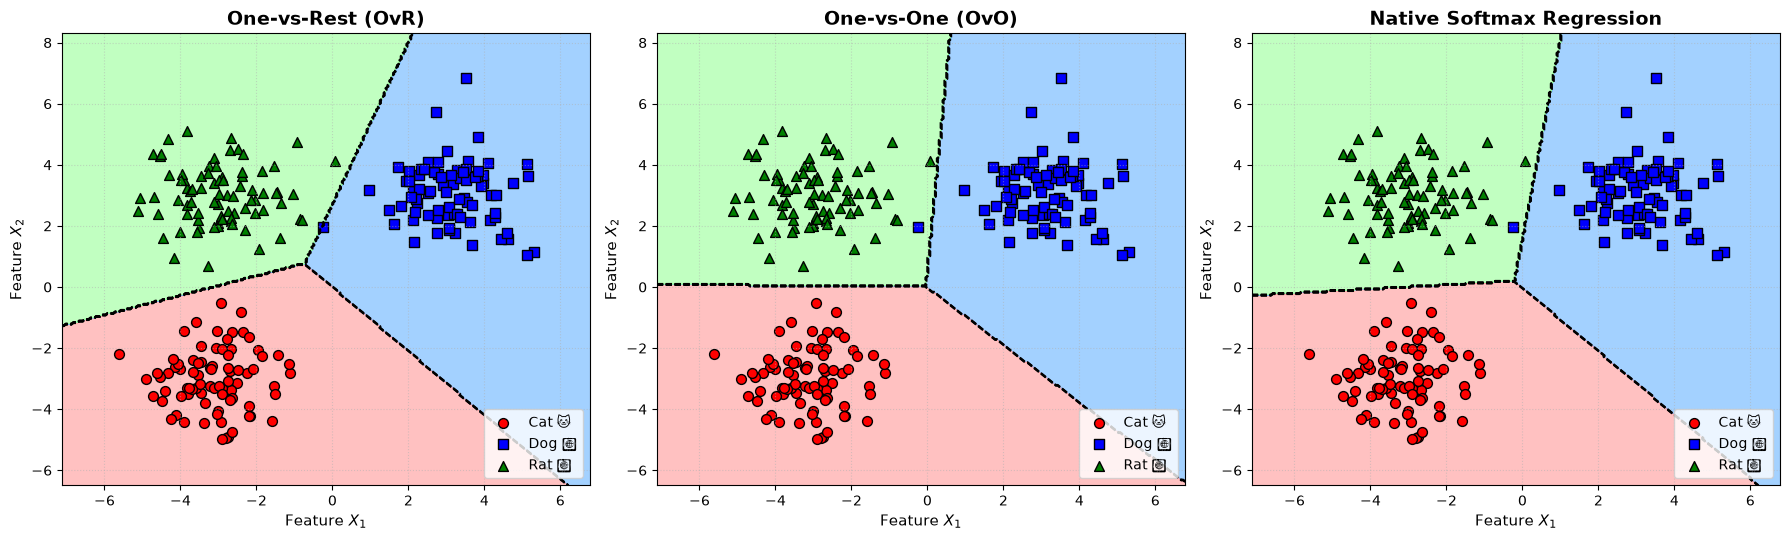

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

if __name__ == "__main__":
    np.random.seed(42)

    # 1. Generate Synthetic 3-Class Clusters
    cluster0 = np.random.randn(80, 2) + np.array([-3, -3])  # Class 0: Cat 🐱
    cluster1 = np.random.randn(80, 2) + np.array([3, 3])    # Class 1: Dog 🐶
    cluster2 = np.random.randn(80, 2) + np.array([-3, 3])   # Class 2: Rat 🐀

    X_train = np.vstack([cluster0, cluster1, cluster2])
    y_train = np.hstack([np.zeros(80), np.ones(80), np.ones(80) * 2]).astype(int)

    # 2. Train All Three Models
    ovr_model = MultiClassLogisticRegression(strategy='ovr', lr=0.1, max_iter=1000).fit(X_train, y_train)
    ovo_model = MultiClassLogisticRegression(strategy='ovo', lr=0.1, max_iter=1000).fit(X_train, y_train)
    softmax_model = SoftmaxRegression(lr=0.1, max_iter=1000).fit(X_train, y_train)

    # -------------------------------------------------------------
    # 3. Create a 2D Mesh Grid for Decision Boundary Plotting
    # -------------------------------------------------------------
    x_min, x_max = X_train[:, 0].min() - 1.5, X_train[:, 0].max() + 1.5
    y_min, y_max = X_train[:, 1].min() - 1.5, X_train[:, 1].max() + 1.5
    
    # Generate fine grid points across feature space
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    # Flatten mesh into a list of (x1, x2) coordinate pairs
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Setup 3-panel side-by-side plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    models = [("One-vs-Rest (OvR)", ovr_model),
              ("One-vs-One (OvO)", ovo_model),
              ("Native Softmax Regression", softmax_model)]

    colors = ['#ff9999', '#66b3ff', '#99ff99']  # Color regions for Cat, Dog, Rat
    cmap_light = plt.cm.colors.ListedColormap(colors)
    cmap_bold = ['red', 'blue', 'green']
    markers = ['o', 's', '^']
    labels = ["Cat 🐱", "Dog 🐶", "Rat 🐀"]

    for idx, (title, clf) in enumerate(models):
        ax = axes[idx]
        
        # Predict class label for every single point on the mesh grid
        Z = clf.predict(grid_points)
        Z = Z.reshape(xx.shape)
        
        # Plot decision region background
        ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
        # Draw explicit decision boundary lines where classes switch
        ax.contour(xx, yy, Z, colors='k', linewidths=1.2, linestyles='--')

        # Scatter plot actual training data on top
        for class_idx in range(3):
            mask = (y_train == class_idx)
            ax.scatter(X_train[mask, 0], X_train[mask, 1], 
                       c=cmap_bold[class_idx], marker=markers[class_idx],
                       edgecolor='k', s=50, label=labels[class_idx])

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel("Feature $X_1$", fontsize=11)
        ax.set_ylabel("Feature $X_2$", fontsize=11)
        ax.legend(loc="lower right")
        ax.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

## Polynomial Feature Transformer

To draw curved (non-linear) decision boundaries, we don't need to change our Softmax math or loss function at all! Instead, we map our original features into a higher-dimensional space using Polynomial Feature Expansion.

**How Polynomial Features Work**

For a 2D dataset with features $\mathbf{x} = [X_1, X_2]$:

- Degree 1 (Linear): $[1, X_1, X_2]$ $\rightarrow$ Straight lines
- Degree 2 (Quadratic): $[1, X_1, X_2, X_1^2, X_1 X_2, X_2^2]$ $\rightarrow$ Ellipses, parabolas, hyperbolas
- Degree 3 (Cubic): $[1, X_1, X_2, X_1^2, X_1 X_2, X_2^2, X_1^3, X_1^2 X_2, X_1 X_2^2, X_2^3]$ $\rightarrow$ Complex curves

When Softmax learns weights $\mathbf{W}$ for these combined polynomial terms, the linear equation in the higher-dimensional space maps back to a curved decision boundary in the original 2D space:
$$w_0 + w_1 X_1 + w_2 X_2 + w_3 X_1^2 + w_4 X_1 X_2 + w_5 X_2^2 = 0$$

C:\Users\Advance Pc\AppData\Local\Temp\ipykernel_16472\3098553517.py:171: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Advance Pc\AppData\Local\Temp\ipykernel_16472\3098553517.py:171: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Advance Pc\AppData\Local\Temp\ipykernel_16472\3098553517.py:171: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


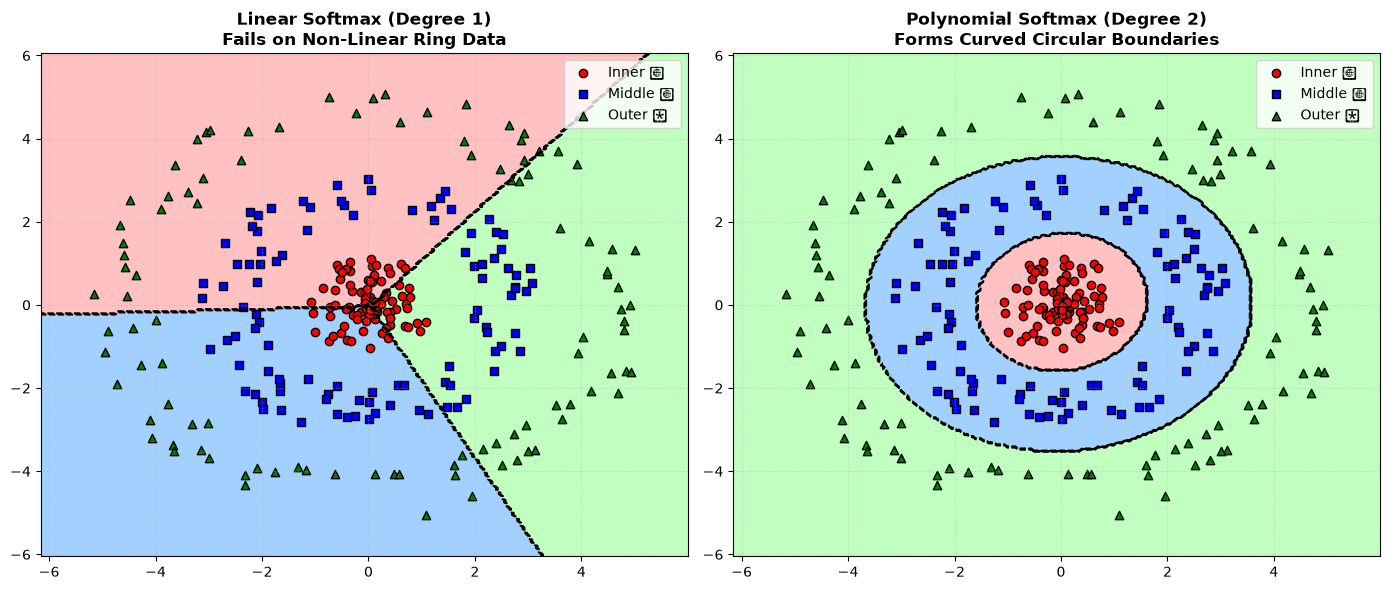

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement

# 1. Standalone Polynomial Feature Transformer (From Scratch)
class PolynomialFeaturesFromScratch:
    """
    Transforms input matrix X of shape (N, d) into polynomial combinations 
    up to a specified degree.
    """
    def __init__(self, degree=2, include_bias=False):
        self.degree = degree
        self.include_bias = include_bias

    def fit_transform(self, X):
        X = np.array(X, dtype=np.float64)
        n_samples, n_features = X.shape

        # Generate index combinations for polynomial powers
        # E.g., for 2 features and degree 2: () [bias], (0,), (1,), (0,0), (0,1), (1,1)
        combo_list = []
        for d in range(0, self.degree + 1):
            for combo in combinations_with_replacement(range(n_features), d):
                combo_list.append(combo)

        if not self.include_bias:
            combo_list = [c for c in combo_list if len(c) > 0]

        n_output_features = len(combo_list)
        X_poly = np.empty((n_samples, n_output_features))

        for i, combo in enumerate(combo_list):
            if len(combo) == 0:
                X_poly[:, i] = 1.0
            else:
                X_poly[:, i] = np.prod(X[:, combo], axis=1)

        return X_poly


# Native Softmax Regression Engine
class SoftmaxRegression:
    def __init__(self, lr=0.1, max_iter=2000, l2_penalty=1e-4, tol=1e-5):
        self.lr = lr
        self.max_iter = max_iter
        self.l2_penalty = l2_penalty
        self.tol = tol
        self.W = None
        self.classes_ = None

    def _softmax(self, Z):
        Z_shifted = Z - np.max(Z, axis=1, keepdims=True)  # Stability trick
        exp_Z = np.exp(Z_shifted)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.int64).flatten()

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_samples, n_features = X.shape

        X_b = np.column_stack([np.ones(n_samples), X])
        Y_one_hot = np.zeros((n_samples, n_classes))
        Y_one_hot[np.arange(n_samples), y] = 1.0

        np.random.seed(42)
        self.W = np.random.randn(n_features + 1, n_classes) * 0.01

        for _ in range(self.max_iter):
            Z = X_b @ self.W
            Y_hat = self._softmax(Z)
            grad = (1.0 / n_samples) * (X_b.T @ (Y_hat - Y_one_hot))
            
            if self.l2_penalty > 0:
                grad[1:] += (self.l2_penalty / n_samples) * self.W[1:]

            W_old = self.W.copy()
            self.W -= self.lr * grad

            if np.max(np.abs(self.W - W_old)) < self.tol:
                break
        return self

    def predict(self, X):
        X = np.array(X, dtype=np.float64)
        X_b = np.column_stack([np.ones(X.shape[0]), X])
        Z = X_b @ self.W
        probs = self._softmax(Z)
        return self.classes_[np.argmax(probs, axis=1)]


# Create Non-Linear Synthetic Dataset (Concentric Rings / Moon Shapes)
def make_concentric_data(n_samples=300):
    np.random.seed(42)
    samples_per_class = n_samples // 3

    # Class 0: Center Circle
    r0 = np.random.uniform(0.0, 1.2, samples_per_class)
    theta0 = np.random.uniform(0, 2 * np.pi, samples_per_class)
    X0 = np.c_[r0 * np.cos(theta0), r0 * np.sin(theta0)]

    # Class 1: Middle Ring
    r1 = np.random.uniform(2.0, 3.2, samples_per_class)
    theta1 = np.random.uniform(0, 2 * np.pi, samples_per_class)
    X1 = np.c_[r1 * np.cos(theta1), r1 * np.sin(theta1)]

    # Class 2: Outer Ring
    r2 = np.random.uniform(4.0, 5.2, samples_per_class)
    theta2 = np.random.uniform(0, 2 * np.pi, samples_per_class)
    X2 = np.c_[r2 * np.cos(theta2), r2 * np.sin(theta2)]

    X = np.vstack([X0, X1, X2])
    y = np.hstack([np.zeros(samples_per_class), np.ones(samples_per_class), np.ones(samples_per_class) * 2]).astype(int)
    return X, y


# Main Execution & Comparison Plotting
if __name__ == "__main__":
    X, y = make_concentric_data(n_samples=300)

    # A. Train Linear Model (Degree 1)
    linear_model = SoftmaxRegression(lr=0.5, max_iter=3000).fit(X, y)

    # B. Train Non-Linear Model (Polynomial Degree 2)
    poly_transformer = PolynomialFeaturesFromScratch(degree=2, include_bias=False)
    X_poly = poly_transformer.fit_transform(X)
    poly_model = SoftmaxRegression(lr=0.5, max_iter=5000, l2_penalty=1e-4).fit(X_poly, y)

    # Create Mesh Grid for Visualization
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Predict Grid Points
    Z_linear = linear_model.predict(grid_points).reshape(xx.shape)
    
    grid_poly = poly_transformer.fit_transform(grid_points)
    Z_poly = poly_model.predict(grid_poly).reshape(xx.shape)

    # Plot Side-by-Side Comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = ['#ff9999', '#66b3ff', '#99ff99']
    cmap_light = plt.cm.colors.ListedColormap(colors)
    cmap_bold = ['red', 'blue', 'green']
    markers = ['o', 's', '^']
    labels = ["Inner 🔴", "Middle 🔵", "Outer 🟢"]

    # --- Subplot 1: Linear Boundary (Degree 1) ---
    axes[0].contourf(xx, yy, Z_linear, cmap=cmap_light, alpha=0.6)
    axes[0].contour(xx, yy, Z_linear, colors='k', linewidths=1.2, linestyles='--')
    for c in range(3):
        mask = (y == c)
        axes[0].scatter(X[mask, 0], X[mask, 1], c=cmap_bold[c], marker=markers[c], edgecolor='k', label=labels[c])
    axes[0].set_title("Linear Softmax (Degree 1)\nFails on Non-Linear Ring Data", fontsize=12, fontweight='bold')
    axes[0].grid(True, linestyle=':', alpha=0.5)
    axes[0].legend()

    # --- Subplot 2: Curved Boundary (Degree 2 Polynomial) ---
    axes[1].contourf(xx, yy, Z_poly, cmap=cmap_light, alpha=0.6)
    axes[1].contour(xx, yy, Z_poly, colors='k', linewidths=1.2, linestyles='--')
    for c in range(3):
        mask = (y == c)
        axes[1].scatter(X[mask, 0], X[mask, 1], c=cmap_bold[c], marker=markers[c], edgecolor='k', label=labels[c])
    axes[1].set_title("Polynomial Softmax (Degree 2)\nForms Curved Circular Boundaries", fontsize=12, fontweight='bold')
    axes[1].grid(True, linestyle=':', alpha=0.5)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

##  Evaluation Metrics

1. The Mathematical Definitions

    For a multi-class problem with $K$ classes, we evaluate each class $k$ by turning it into a binary perspective: **Class $k$ vs. All Other Classes.**
    
    **Per-Class Building Blocks:**
    - True Positive ($\text{TP}_k$): Actual class $k$, predicted as class $k$.
    - False Positive ($\text{FP}_k$): Actual class $\neq k$, predicted as class $k$.
    - False Negative ($\text{FN}_k$): Actual class $k$, predicted as class $\neq k$.
    - True Negative ($\text{TN}_k$): Actual class $\neq k$, predicted as class $\neq k$.
    
    **Per-Class Metrics**
    - Precision ($\text{P}_k$): Out of all instances predicted as class $k$, how many were correct?
    $$\text{P}_k = \frac{\text{TP}_k}{\text{TP}_k + \text{FP}_k}$$
    
    - Recall ($\text{R}_k$): Out of all actual instances of class $k$, how many did we catch?
    $$\text{R}_k = \frac{\text{TP}_k}{\text{TP}_k + \text{FN}_k}$$
    
    - $F_1$-Score ($F_{1, k}$): Harmonic mean of Precision and Recall for class $k$:
    $$F_{1, k} = 2 \cdot \frac{\text{P}_k \cdot \text{R}_k}{\text{P}_k + \text{R}_k}$$

2. Aggregation Strategies: Macro vs. Micro

    When summarizing performance across all $K$ classes into a single number:
    
    1. **Macro Averaging (Equal Weight to Every Class)**
    
        Calculates the metric independently for each class and takes the unweighted mean. This treats small classes with equal importance to large ones:
        $$\text{Macro-P} = \frac{1}{K} \sum_{k=1}^{K} \text{P}_k, \quad \text{Macro-R} = \frac{1}{K} \sum_{k=1}^{K} \text{R}_k, \quad \text{Macro-}F_1 = \frac{1}{K} \sum_{k=1}^{K} F_{1, k}$$
    
    2. **Micro Averaging (Global Sample Weighting)**
    
        Aggregates total $\text{TP}, \text{FP}, \text{FN}$ counts across all classes first before computing the metric. This gives equal weight to every individual sample:
        
        $$\text{Micro-P} = \frac{\sum_{k=1}^{K} \text{TP}_k}{\sum_{k=1}^{K} (\text{TP}_k + \text{FP}_k)}, \quad \text{Micro-R} = \frac{\sum_{k=1}^{K} \text{TP}_k}{\sum_{k=1}^{K} (\text{TP}_k + \text{FN}_k)}$$
        $$\text{Micro-}F_1 = 2 \cdot \frac{\text{Micro-P} \cdot \text{Micro-R}}{\text{Micro-P} + \text{Micro-R}}$$
        
        **Key Insight:** For multi-class single-label classification (where every sample belongs to exactly one class), $\sum \text{FP}_k = \sum \text{FN}_k$. As a result, $\text{Micro-P} = \text{Micro-R} = \text{Micro-}F_1 = \text{Accuracy}$.

In [10]:
import numpy as np

def confusion_matrix(y_true, y_pred, n_classes=None):
    """
    Computes a K x K Confusion Matrix.
    Rows = True Classes, Columns = Predicted Classes.
    """
    y_true = np.array(y_true, dtype=np.int64).flatten()
    y_pred = np.array(y_pred, dtype=np.int64).flatten()

    if n_classes is None:
        n_classes = max(y_true.max(), y_pred.max()) + 1

    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    
    # Vectorized indexing into matrix coordinates
    np.add.at(cm, (y_true, y_pred), 1)
    return cm


def evaluate_multiclass(y_true, y_pred, class_names=None):
    """
    Calculates Per-Class and Aggregated (Macro/Micro) Precision, Recall, and F1-Score.
    """
    y_true = np.array(y_true, dtype=np.int64).flatten()
    y_pred = np.array(y_pred, dtype=np.int64).flatten()

    classes = np.unique(np.concatenate([y_true, y_pred]))
    K = len(classes)

    if class_names is None:
        class_names = [f"Class {c}" for c in classes]

    cm = confusion_matrix(y_true, y_pred, n_classes=K)

    # Containers for per-class counts
    tp = np.zeros(K)
    fp = np.zeros(K)
    fn = np.zeros(K)

    for k in range(K):
        tp[k] = cm[k, k]
        fp[k] = np.sum(cm[:, k]) - tp[k]   # Column sum minus TP
        fn[k] = np.sum(cm[k, :]) - tp[k]   # Row sum minus TP

    # Safe division to handle potential 0 denominators
    eps = 1e-15
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * (precision * recall) / (precision + recall + eps)

    # Macro Metrics
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1)

    # Micro Metrics
    total_tp = np.sum(tp)
    total_fp = np.sum(fp)
    total_fn = np.sum(fn)

    micro_precision = total_tp / (total_tp + total_fp + eps)
    micro_recall = total_tp / (total_tp + total_fn + eps)
    micro_f1 = 2 * (micro_precision * micro_recall) / (micro_precision + micro_recall + eps)

    accuracy = np.mean(y_true == y_pred)

    metrics_summary = {
        "confusion_matrix": cm,
        "per_class": {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": np.sum(cm, axis=1)  # Number of actual instances per class
        },
        "macro": {
            "precision": macro_precision,
            "recall": macro_recall,
            "f1": macro_f1
        },
        "micro": {
            "precision": micro_precision,
            "recall": micro_recall,
            "f1": micro_f1
        },
        "accuracy": accuracy
    }

    return metrics_summary


def print_classification_report(metrics, class_names):
    """Prints a formatted classification table similar to scikit-learn."""
    cm = metrics["confusion_matrix"]
    per_class = metrics["per_class"]
    macro = metrics["macro"]
    micro = metrics["micro"]

    print("\n=========================================================")
    print("                CONFUSION MATRIX (K x K)                 ")
    print("=========================================================")
    header = "True \\ Pred | " + " ".join([f"{name[:7]:>8}" for name in class_names])
    print(header)
    print("-" * len(header))
    for i, row_name in enumerate(class_names):
        row_str = " ".join([f"{val:8d}" for val in cm[i]])
        print(f"{row_name[:11]:<11} | {row_str}")

    print("\n=========================================================")
    print("             CLASSIFICATION PERFORMANCE REPORT           ")
    print("=========================================================")
    print(f"{'Class':<12} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'Support':<8}")
    print("-" * 62)

    for i, name in enumerate(class_names):
        p = per_class["precision"][i]
        r = per_class["recall"][i]
        f = per_class["f1"][i]
        s = per_class["support"][i]
        print(f"{name:<12} | {p:10.4f} | {r:10.4f} | {f:10.4f} | {s:8d}")

    print("-" * 62)
    print(f"{'Accuracy':<12} | {'':<10} | {'':<10} | {metrics['accuracy']:10.4f} | {np.sum(per_class['support']):8d}")
    print(f"{'Macro Avg':<12} | {macro['precision']:10.4f} | {macro['recall']:10.4f} | {macro['f1']:10.4f} | {np.sum(per_class['support']):8d}")
    print(f"{'Micro Avg':<12} | {micro['precision']:10.4f} | {micro['recall']:10.4f} | {micro['f1']:10.4f} | {np.sum(per_class['support']):8d}")


# Test Bench with Imbalanced Synthetic Data & Edge Case Misclassifications
if __name__ == "__main__":
    np.random.seed(42)

    # Simulated targets for 3 classes (Cat=0, Dog=1, Rat=2) with forced errors
    y_true = np.array([0]*50 + [1]*30 + [2]*20)  # Imbalanced: 50 Cats, 30 Dogs, 20 Rats
    y_pred = y_true.copy()

    # Inject realistic errors:
    # 3 Cats misclassified as Rats
    y_pred[2] = 2; y_pred[5] = 2; y_pred[8] = 2
    # 2 Dogs misclassified as Cats
    y_pred[52] = 0; y_pred[55] = 0
    # 4 Rats misclassified as Dogs
    y_pred[82] = 1; y_pred[84] = 1; y_pred[86] = 1; y_pred[88] = 1

    labels = ["Cat 🐱", "Dog 🐶", "Rat 🐀"]

    results = evaluate_multiclass(y_true, y_pred, class_names=labels)
    print_classification_report(results, class_names=labels)


                CONFUSION MATRIX (K x K)                 
True \ Pred |    Cat 🐱    Dog 🐶    Rat 🐀
----------------------------------------
Cat 🐱       |       47        0        3
Dog 🐶       |        2       28        0
Rat 🐀       |        0        4       16

             CLASSIFICATION PERFORMANCE REPORT           
Class        | Precision  | Recall     | F1-Score   | Support 
--------------------------------------------------------------
Cat 🐱        |     0.9592 |     0.9400 |     0.9495 |       50
Dog 🐶        |     0.8750 |     0.9333 |     0.9032 |       30
Rat 🐀        |     0.8421 |     0.8000 |     0.8205 |       20
--------------------------------------------------------------
Accuracy     |            |            |     0.9100 |      100
Macro Avg    |     0.8921 |     0.8911 |     0.8911 |      100
Micro Avg    |     0.9100 |     0.9100 |     0.9100 |      100
